In [ ]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import numpy as np
import torch


In [ ]:
ds = datasets.MNIST("", train=True, transform=ToTensor(), download=True)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting MNIST/raw/train-images-idx3-ubyte.gz to MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting MNIST/raw/train-labels-idx1-ubyte.gz to MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST/raw



In [ ]:
np.array(ds[0][0]).shape

(1, 28, 28)

In [ ]:
ld = DataLoader(ds, 32, True)

In [ ]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 200),
                    nn.LeakyReLU(),
                    nn.Linear(200, 100),
                    nn.LeakyReLU(),
                    nn.Linear(100, 10))

In [ ]:
opt = torch.optim.SGD(net.parameters(),3e-3)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
numIters = 5
accuracies = []
losses = []
for _ in tqdm(range(numIters)):
    epochAccuracies = []
    epochLosses = []
    for x, y in tqdm(ld):
        pred = net(x)
        err = criterion(pred, y)
        err.backward()
        opt.step()
        opt.zero_grad()
        loss = err.item()
        accuracy = torch.mean((torch.argmax(pred, 1)==y).float())
        epochAccuracies.append(accuracy)
        epochLosses.append(loss)
    accuracies.append(sum(epochAccuracies)/len(epochAccuracies))
    losses.append(sum(epochLosses)/len(epochLosses))
plt.figure()
plt.title('accuracies')
plt.plot(accuracies)
plt.figure()
plt.title('losses')
plt.plot(losses)

In [ ]:
validds = datasets.MNIST('.', download=True, train=False, transform=ToTensor())

In [ ]:
testld = DataLoader(validds, 32, True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

...

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

<function matplotlib.pyplot.legend>

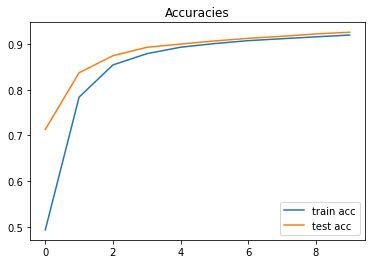

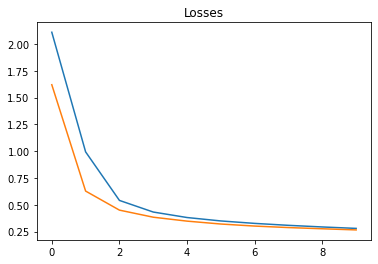

In [ ]:
numEpochs = 10
accuraciesTrain = []
lossesTrain = []
accuraciesTest = []
lossesTest = []
for _ in tqdm(range(numEpochs)):
    epochTrainAccuracies = []
    epochTrainLosses = []
    epochTestAccuracies = []
    epochTestLosses = []
    for xtrain, ytrain in tqdm(ld):
        pred = net(xtrain)
        err = criterion(pred, ytrain)
        err.backward()
        opt.step()
        opt.zero_grad()
        loss = err.item()
        accuracy = torch.mean((torch.argmax(pred, 1)==ytrain).float())
        epochTrainAccuracies.append(accuracy)
        epochTrainLosses.append(loss)
    for xtest, ytest in testld:
        pred = net(xtest)
        err = criterion(pred, ytest)
        epochTestAccuracies.append(torch.mean((torch.argmax(pred, 1)==ytest).float()))
        epochTestLosses.append(err.item())
    accuraciesTrain.append(sum(epochTrainAccuracies)/len(epochTrainAccuracies))
    lossesTrain.append(sum(epochTrainLosses)/len(epochTrainLosses))
    accuraciesTest.append(sum(epochTestAccuracies)/len(epochTestAccuracies))
    lossesTest.append(sum(epochTestLosses)/len(epochTestLosses))
plt.figure()
plt.title('Accuracies')
plt.plot(accuraciesTrain, Label='train acc')
plt.plot(accuraciesTest, Label='test acc')
plt.legend()
plt.figure()
plt.title('Losses')
plt.plot(lossesTrain, label='train loss')
plt.plot(lossesTest, label='test loss')
plt.legend

In [ ]:
accuraciestest = []
losstest = []
for xtest, ytest in tqdm(testld):
    pred = net(xtest)
    err = criterion(pred, ytest)
    losstest.append(err.item())
    accuraciestest.append(torch.mean((torch.argmax(pred, 1)==ytest).float()))
print(f'{sum(accuraciestest)/len(accuraciestest)} - accuracy')
print(f'{sum(losstest)/len(losstest)} - loss')

  0%|          | 0/313 [00:00<?, ?it/s]

0.00738817872479558 - accuracy
0.9344870052017724 - loss


In [ ]:
testx, testy = next(iter(testld))
print(f'{torch.argmax(net(testx), dim=1)} - prediction')
print(f'{testy} - target')

tensor([5, 0, 3, 7, 9, 3, 0, 5, 6, 7, 9, 6, 6, 9, 2, 5, 8, 1, 9, 9, 1, 1, 6, 3,
        7, 6, 4, 4, 6, 4, 7, 7]) - prediction
tensor([0, 0, 3, 8, 4, 3, 0, 8, 6, 9, 4, 6, 6, 9, 2, 5, 8, 1, 7, 9, 1, 1, 6, 2,
        7, 6, 4, 4, 6, 5, 7, 7]) - target


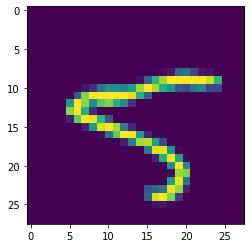

In [ ]:
plt.imshow(testx[-3].reshape(28, 28))